In [1]:
# libraries for data loading and system/path settings
import json
import sys
import gc
import warnings
import os
from pathlib import Path

# libraries for model building and training
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, logging
import torch
from torch.utils.data import Dataset
import optuna
from functools import partial

# set path to project root and import custom classes and functions
base_path = Path.cwd() / "../../"
sys.path.append(str(base_path.resolve()))
from utils.classification import EarlyStopping, tune_bert_ner_optuna
from utils.evaluation import cross_validation
from utils.visualizations import plot_losses_f1

# global settings to suppress unproblematic warning messages
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="The sentencepiece tokenizer")

In [2]:
# load the annotated data in json format
with open("../../01_data/annotations_reduced.json", "r") as f:
    data = json.load(f)

# initialize tag dictionary
tag_dict = {"O"}

# loop through all sentences
for task in data:
    if task["annotations"]:
        for annotation in task["annotations"]:
            label = annotation["tag"][0:2]
            tag_dict.add(f"B-{label}")
            tag_dict.add(f"I-{label}")

# sort the tag dictionary
tag_list = sorted(tag_dict)

# dictionaries that convert from id to tag and vice versa
tag_to_id = {tag: i for i, tag in enumerate(tag_list)}
id_to_tag = {id: label for label, id in tag_to_id.items()}

In [3]:
def tokenization_labelling(text, entities, tokenizer, tag2id, max_len):

    # get the encoding of the sentence
    encoding = tokenizer(text, return_offsets_mapping=True, truncation=True,
                         max_length=max_len, padding="max_length")
    
    # create preliminary list with O tags for all tokens
    tags = ["O"] * len(encoding.offset_mapping)

    # loop over annotations and extract start and end index as well as the given tag
    for ent in entities:
        start, end = ent["start"], ent["end"]
        ent_tag = ent["tag"][0:2]

        # loop over all tokens in the sentence and check for overlap
        for idx, (token_start, token_end) in enumerate(encoding.offset_mapping):
            # continue if it is a special token
            if token_start == token_end == 0:
                continue
            # check for overlap (overlap checking strictly necessary for deberta)
            if token_end > start and token_start < end:
                # assign B-tag if start is equal or smaller (smaller if deberta)
                if token_start <= start:
                    tags[idx] = f"B-{ent_tag}"
                # otherwise it is an inside token
                else:
                    tags[idx] = f"I-{ent_tag}"

    # extract the word ids
    word_ids = encoding.word_ids()

    # ensure propagate B-tags are propagated to all subwords of the same word (only actually relevant for deberta)
    for idx, wid in enumerate(word_ids):
        if wid is None:
            continue
        # if token has B-tag ensure that all other tokens of the same word get I-tag
        if tags[idx].startswith("B-"):
            for j, wid2 in enumerate(word_ids):
                if wid2 == wid and j != idx:
                    tags[j] = f"I-{ent_tag}"

    # convert tags to IDs, masking special tokens
    tag_ids = [-100 if wid is None else tag2id.get(tag, tag2id["O"])
               for tag, wid in zip(tags, encoding.word_ids())]

    return encoding["input_ids"], encoding["attention_mask"], tag_ids, word_ids

In [4]:
# split into training, validation and test dataset
train_data, val_data = train_test_split(data, test_size=0.2, shuffle=True, random_state=42)

class TokenDataset(Dataset):
    def __init__(self, data, tokenizer, tag2id, max_len):
        self.dataset = []
        self.max_len = max_len

        for task in data:
            # get the sentence and all annotations
            text = task["sentence"]
            spans = task["annotations"]

            # tokenize and get all ids
            input_ids, attention_mask, tag_ids, word_ids = tokenization_labelling(text, spans, tokenizer, tag2id, self.max_len)

            # add everything to the dataset list
            self.dataset.append({
                "input_ids": torch.tensor(input_ids, dtype=torch.long),
                "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
                "tag_ids": torch.tensor(tag_ids, dtype=torch.long),
                "word_ids": word_ids})
  

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

def custom_collate_fn(batch):
    input_ids = torch.stack([item["input_ids"] for item in batch])
    attention_masks = torch.stack([item["attention_mask"] for item in batch])
    tag_ids = torch.stack([item["tag_ids"] for item in batch])
    word_ids = [item["word_ids"] for item in batch]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_masks,
        "tag_ids": tag_ids,
        "word_ids": word_ids
    }

In [5]:
# hyperparameter tuning with TPE implemented via Optuna

# define the objective function whose output optuna tries to maximize
def objective(trial, model_name, train_dataset, val_dataset, collate_fn, tag2id, id2tag, device, early_stopper):

    # hyperparameter space in which optuna can search
    params = {
        "lr": trial.suggest_categorical("lr", [9e-6, 2e-5, 4e-5]),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "weight_decay": trial.suggest_categorical("weight_decay", [0.01, 0.1, 0.3]),
        "epochs": trial.suggest_categorical("epochs", [2, 2, 2])
    }

    # train the model with these hyperparameters
    best_f1, best_epoch, train_losses, val_losses, f1_scores_train, f1_scores_val = tune_bert_ner_optuna(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        collate_fn=collate_fn,
        model_name=model_name,
        tag2id=tag2id,
        id2tag=id2tag,
        device=device,
        early_stopper=early_stopper,
        params=params
    )

    # besides parameters, save losses and f1-scores in the trial object
    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)
    trial.set_user_attr("f1_scores_train", f1_scores_train)
    trial.set_user_attr("f1_scores_val", f1_scores_val)

    return best_f1


# dictionary to save optimal paramaters
optimal_configs = {}

# number of trials, the device on which models should operate and the specific models to test
num_trials = 2
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_names = ["roberta-base", "bert-base-cased", "distilbert-base-cased", "microsoft/deberta-v3-base"]

# loop over the models
for model_name in model_names:

    print(f"\nStarting search for model: {model_name}")
    print("-"*200)

    # create a new optuna study, tokenizer fitting to the model as well as train and validation set
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = TokenDataset(data=train_data, tokenizer=tokenizer, tag2id=tag_to_id, max_len=128)
    val_dataset = TokenDataset(data=val_data, tokenizer=tokenizer, tag2id=tag_to_id, max_len=128)

    # set model name for output path
    if model_name == "microsoft/deberta-v3-base":
        output_path = "model_saves/deberta.pt"
    else:
        output_path = f"model_saves/{model_name}.pt"

    # run the optimization loop
    study.optimize(
        partial(objective,
                model_name=model_name,
                train_dataset=train_dataset,
                val_dataset=val_dataset,
                collate_fn=custom_collate_fn,
                tag2id=tag_to_id,
                id2tag=id_to_tag,
                device=device,
                early_stopper=EarlyStopping(patience=3, path=output_path, printoption=True)),
        n_trials=num_trials
    )

    # get the best trial and save optimal parameters
    best_trial = study.best_trial
    optimal_configs[model_name] = {
        "best_f1": best_trial.value,
        "best_params": best_trial.params,
        "best_epoch": best_trial.user_attrs["best_epoch"],
        "train_losses": best_trial.user_attrs["train_losses"],
        "val_losses": best_trial.user_attrs["val_losses"],
        "f1_scores_train": best_trial.user_attrs["f1_scores_train"],
        "f1_scores_val": best_trial.user_attrs["f1_scores_val"]
    }

    # clean all objects and empty cache for the next model
    del study, tokenizer, train_dataset, val_dataset
    gc.collect()
    torch.mps.empty_cache()

    print("-"*200)

[I 2025-11-06 11:07:24,718] A new study created in memory with name: no-name-c22b9e63-6ca6-4585-9d1b-533e81de649e



Starting search for model: roberta-base
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Trial with params: {'lr': 4e-05, 'batch_size': 8, 'weight_decay': 0.1, 'epochs': 2}
Epoch 1/2


Training: 100%|██████████| 300/300 [01:13<00:00,  4.10it/s, loss=0.193]   


Average training loss: 0.1060
Validation F1 increased (0.762353 --> 0.762353).  Saving model ...
Epoch 2/2


Training:  18%|█▊        | 53/300 [00:13<01:01,  4.03it/s, loss=0.0158] 
[W 2025-11-06 11:09:15,422] Trial 0 failed with parameters: {'lr': 4e-05, 'batch_size': 8, 'weight_decay': 0.1, 'epochs': 2} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/p7/w5d7hqvx77ldbc1kmnl49v800000gn/T/ipykernel_3350/3537262941.py", line 15, in objective
    best_f1, best_epoch, train_losses, val_losses, f1_scores_train, f1_scores_val = tune_bert_ner_optuna(
                                                                                    ~~~~~~~~~~~~~~~~~~~~^
        train_dataset=train_dataset,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<7 lines>...
        params=params
        ^^^^^^^^^^^^^
    )
    ^
  File "/Users/maxweiland/Desktop/SEDS/Master_Thesis/utils/cla

KeyboardInterrupt: 

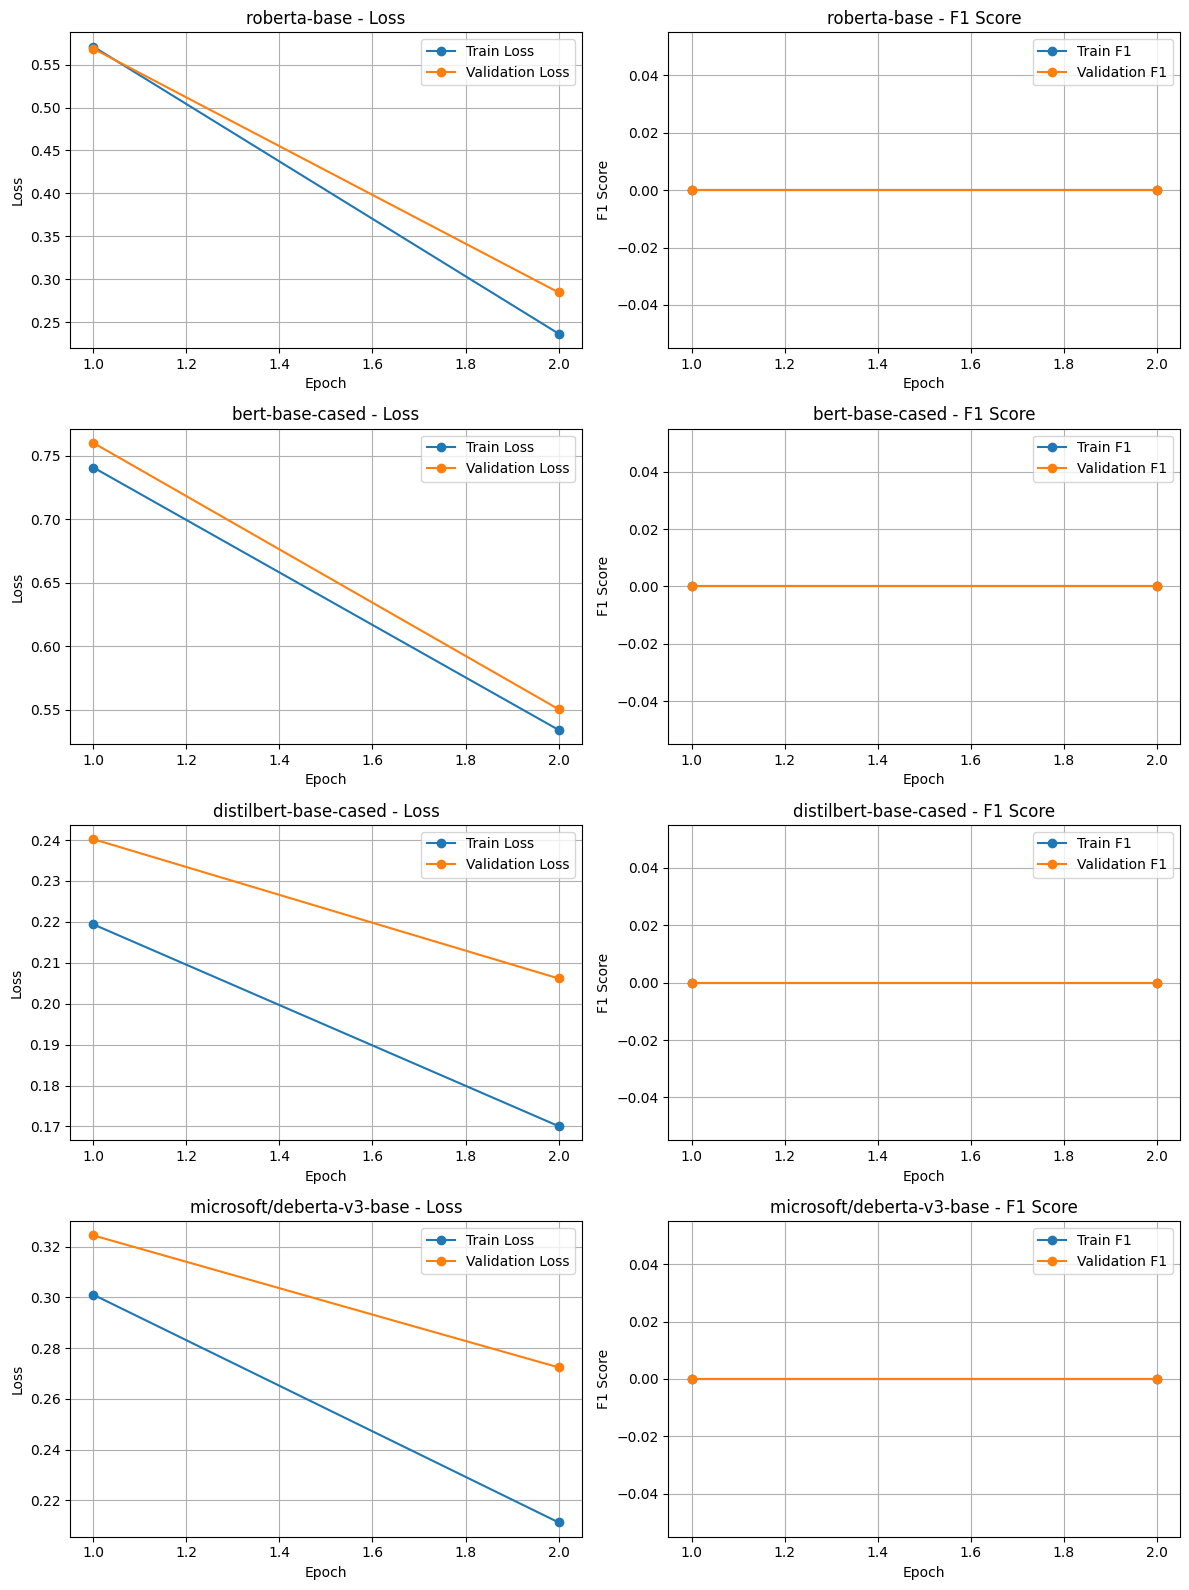

In [8]:
# plot the development of F1 scores and losses for the tuned models
plot_losses_f1(model_names, optimal_configs)

In [14]:
# apply cross validation to all models with their best hyperparameters
average_metrics = cross_validation(model_names=model_names, training_data=train_data, dataset_class=TokenDataset,
                                   label2id=tag_to_id, id2label=id_to_tag, num_folds=5, optimal_configurations=optimal_configs,
                                   classification_task="ner")

# export the cross-validation metrics
with open("eval_results/evaluation_metrics_bert.json", "w") as f:
    json.dump(average_metrics, f, indent=4)


Cross-validation for model roberta-base starts
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Fold number: 1
Epoch 1/1


Training: 100%|██████████| 4/4 [00:01<00:00,  2.10it/s, loss=0.79] 


Average training loss: 1.0546

Fold number: 2
Epoch 1/1


Training: 100%|██████████| 4/4 [00:01<00:00,  2.34it/s, loss=0.419]


Average training loss: 0.6040


...

Average training loss: 0.7650

Fold number: 4
Epoch 1/1


Training: 100%|██████████| 2/2 [00:15<00:00,  7.81s/it, loss=0.716]


Average training loss: 1.0280

Fold number: 5
Epoch 1/1


Training: 100%|██████████| 2/2 [00:13<00:00,  6.97s/it, loss=nan] 


Average training loss: nan
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [10]:
def predict_sentence(sentence, model, tokenizer, id_to_label, device='mps'):

    model.eval()

    # tokenize the input sentence
    encoding = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=128
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    offset_mapping = encoding["offset_mapping"][0]

    # inference with autocast for mixed precision
    with torch.no_grad():
        with torch.autocast(device_type=device, dtype=torch.float16):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)[0]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    labels = [id_to_label[pred.item()] for pred in predictions]

    result = []
    for token, label, (start, end) in zip(tokens, labels, offset_mapping):
        if start == 0 and end == 0:
            continue
        token_text = sentence[start:end]
        result.append((token_text, label))

    return result

In [14]:
# try out a custom sentence
text = "We want to protect women."
predict_sentence(text, model=model, tokenizer=tokenizer, id_to_label=id_to_tag)

[('We', 'O'),
 (' want', 'O'),
 (' to', 'O'),
 (' protect', 'O'),
 (' women', 'B-sg'),
 ('.', 'I-sg')]